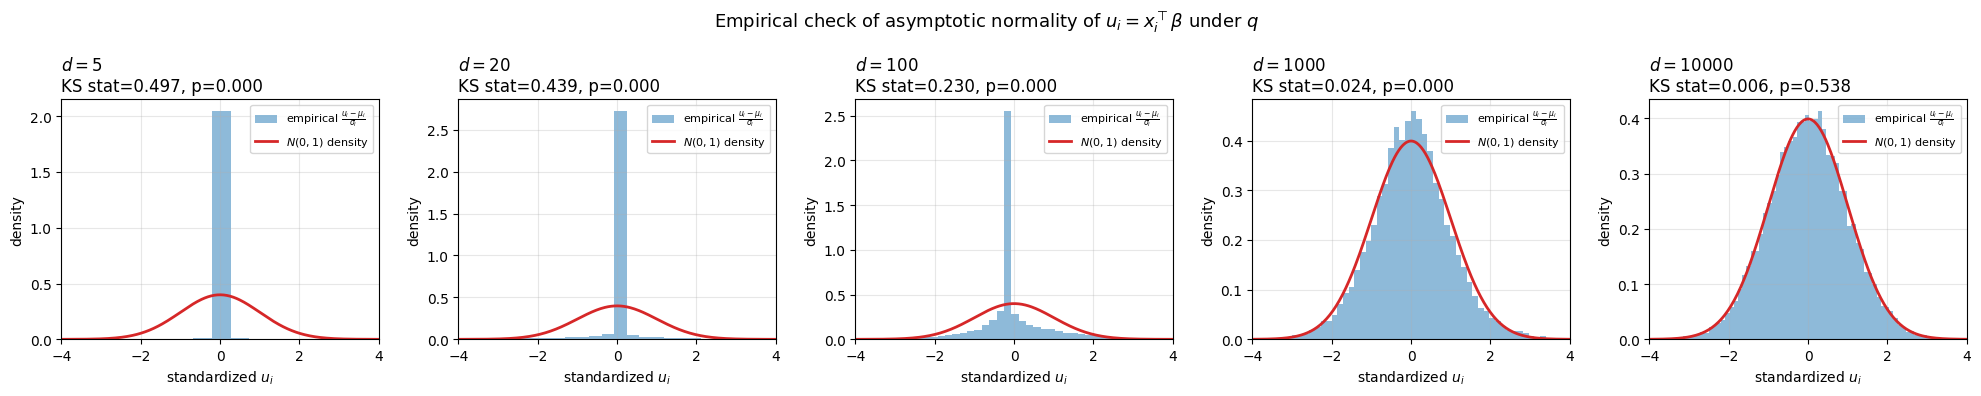

     d |   skewness |  excess kurtosis |  KS stat | KS p-value
     5 |     5.3031 |          65.0726 |   0.4990 |     0.0000
    20 |    -4.2503 |          40.2775 |   0.4367 |     0.0000
   100 |     1.0040 |           4.6805 |   0.2111 |     0.0000
  1000 |    -0.0644 |           0.8946 |   0.0240 |     0.0000
 10000 |    -0.0236 |           0.1274 |   0.0090 |     0.0768


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Simulation: check asymptotic normality of u_i = x_i^T beta
# under the variational spike-and-slab distribution q(beta, z),
# as d -> infinity (Lemma on CLT for spike-and-slab).
# ============================================================

rng = np.random.default_rng(42)

# ---------- variational / prior-like parameters ----------
pi0 = 0.01          # gamma_j = P_q(z_j = 1), fixed, independent of d
m_val = 0.5        # variational mean m_j (same for all j, for simplicity)
rho_val = 1.0      # variational variance rho_j (same for all j)

# design point x_i: entries bounded, e.g. i.i.d. from Uniform(-1,1)
def sample_design(d, rng):
    return rng.uniform(-1, 1, size=d)

def sample_design_correlated(d, rng, block_size=10, rho=0.9):
    """
    Sample a single design vector x_i in R^d with a block-correlation structure:
    entries are partitioned into contiguous blocks of size `block_size`, and
    within each block the entries are jointly Gaussian with correlation `rho`
    (compound-symmetry / equicorrelated structure). Different blocks are
    independent of each other. The last block may be smaller than block_size
    if d is not a multiple of block_size.

    Marginally, each entry has mean 0 and variance 1.

    Parameters
    ----------
    d : int
        Dimension of the design vector.
    rng : np.random.Generator
        Random number generator.
    block_size : int
        Size of each correlated block (k).
    rho : float
        Within-block correlation, must satisfy -1/(block_size-1) < rho < 1
        for the covariance matrix to be positive semi-definite.

    Returns
    -------
    x_i : np.ndarray of shape (d,)
    """
    x_i = np.empty(d)
    start = 0
    while start < d:
        k = min(block_size, d - start)
        # Equicorrelated covariance: Sigma = (1-rho) * I_k + rho * ones(k,k)
        Sigma = (1 - rho) * np.eye(k) + rho * np.ones((k, k))
        block_sample = rng.multivariate_normal(np.zeros(k), Sigma)
        x_i[start:start + k] = block_sample
        start += k
    return x_i

# ---------- exact sampler for u_i^(d) = sum_j x_i^(j) * beta_j ----------
def sample_u(d, n_samples, rng, pi0=pi0, m_val=m_val, rho_val=rho_val):
    x_i = sample_design_correlated(d, rng)

    # sample z_j ~ Bernoulli(pi0) and beta_j | z_j from the mixture,
    # for each of n_samples independent draws of beta (Monte Carlo over q)
    z = rng.binomial(1, pi0, size=(n_samples, d))
    beta_slab = rng.normal(m_val, np.sqrt(rho_val), size=(n_samples, d))
    beta = z * beta_slab  # beta_j = 0 when z_j = 0 (spike), else slab draw

    u = beta @ x_i  # shape (n_samples,)
    return u, x_i

# ---------- theoretical mean/variance from the lemma ----------
def theoretical_mean_var(x_i, pi0=pi0, m_val=m_val, rho_val=rho_val):
    gamma = pi0  # constant gamma_j = pi0 here
    v_j = gamma * (rho_val + m_val**2) - gamma**2 * m_val**2  # Var_q(beta_j)
    mu_i = np.sum(x_i * gamma * m_val)
    sigma2_i = np.sum(x_i**2 * v_j)
    return mu_i, sigma2_i

# ---------- run simulation for increasing d ----------
d_values = [5, 20, 100, 1000, 10_000]
n_samples = 20_000

fig, axes = plt.subplots(1, len(d_values), figsize=(4 * len(d_values), 4))

for ax, d in zip(axes, d_values):
    u, x_i = sample_u(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var(x_i)
    sigma_i = np.sqrt(sigma2_i)

    # standardize using theoretical mean/variance
    u_std = (u - mu_i) / sigma_i

    # empirical histogram vs. standard normal density
    ax.hist(u_std, bins=80, density=True, alpha=0.5, color='tab:blue',
             label='empirical $\\frac{u_i-\\mu_i}{\\sigma_i}$')
    grid = np.linspace(-4, 4, 300)
    ax.plot(grid, stats.norm.pdf(grid), color='tab:red', linewidth=2,
             label='$N(0,1)$ density')

    # quantify deviation from normality
    ks_stat, ks_pval = stats.kstest(u_std, 'norm')

    ax.set_title(f'$d={d}$\nKS stat={ks_stat:.3f}, p={ks_pval:.3f}', loc='left')
    ax.set_xlabel(r'standardized $u_i$')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.set_xlim(-4, 4)
    ax.grid(alpha=0.3)

fig.suptitle('Empirical check of asymptotic normality of $u_i = x_i^\\top\\beta$ under $q$', fontsize=13)
plt.tight_layout()
plt.savefig('clt_spike_and_slab_check.png', dpi=150)
plt.show()

# ---------- additional numeric diagnostics ----------
print(f"{'d':>6} | {'skewness':>10} | {'excess kurtosis':>16} | {'KS stat':>8} | {'KS p-value':>10}")
for d in d_values:
    u, x_i = sample_u(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var(x_i)
    u_std = (u - mu_i) / np.sqrt(sigma2_i)
    skew = stats.skew(u_std)
    kurt = stats.kurtosis(u_std)  # excess kurtosis (0 for normal)
    ks_stat, ks_pval = stats.kstest(u_std, 'norm')
    print(f"{d:6d} | {skew:10.4f} | {kurt:16.4f} | {ks_stat:8.4f} | {ks_pval:10.4f}")

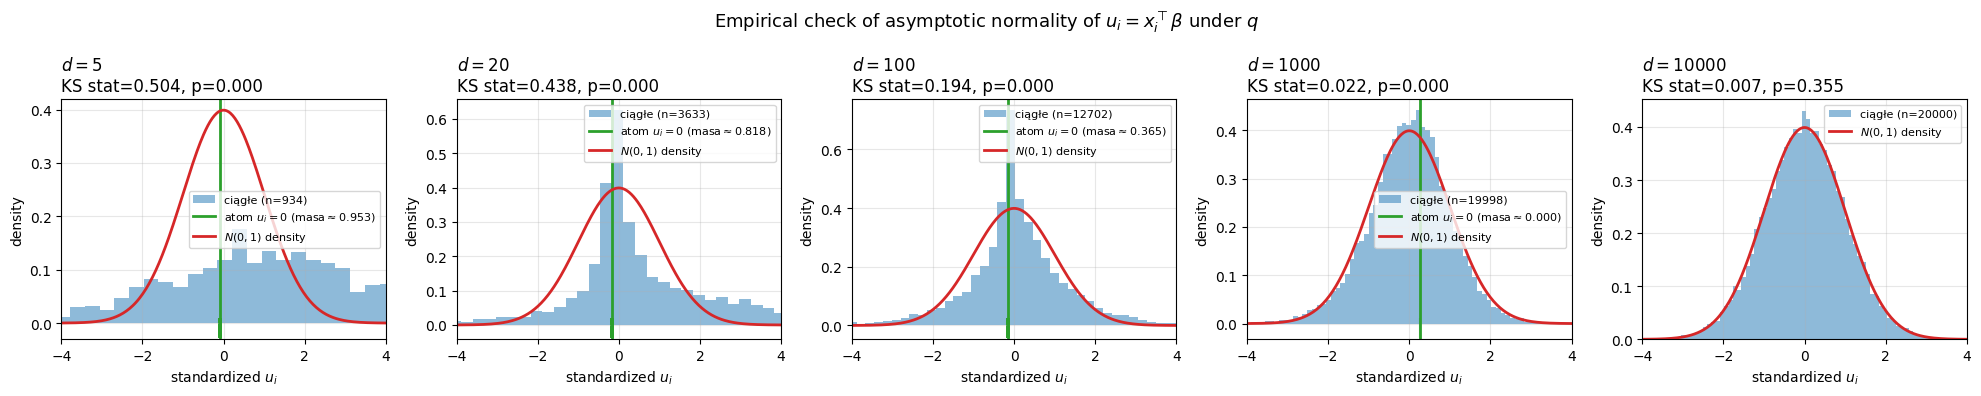

In [7]:
fig, axes = plt.subplots(1, len(d_values), figsize=(4 * len(d_values), 4))
for ax, d in zip(axes, d_values):
    u, x_i = sample_u(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var(x_i)
    sigma_i = np.sqrt(sigma2_i)
    # standardize using theoretical mean/variance
    u_std = (u - mu_i) / sigma_i

    # rozdzielenie: atom w zerze (u dokładnie 0) vs. część ciągła
    is_zero = (u == 0)
    u_std_zero = u_std[is_zero]
    u_std_cont = u_std[~is_zero]

    frac_zero = is_zero.mean()

    # histogram części ciągłej
    ax.hist(u_std_cont, bins=80, density=True, alpha=0.5, color='tab:blue',
             label=f'ciągłe (n={(~is_zero).sum()})')

    # atom w zerze jako pionowa linia / słupek o wysokości = masa atomu (po standaryzacji)
    if is_zero.any():
        ax.axvline(u_std_zero[0], color='tab:green', linewidth=2,
                   label=f'atom $u_i=0$ (masa$\\approx${frac_zero:.3f})')
        # opcjonalnie: zaznacz punkty na osi x (rug plot) zamiast histogramu,
        # bo to pojedyncza wartość (u_std_zero powinno być identyczne dla wszystkich)
        ax.scatter(u_std_zero, np.zeros_like(u_std_zero) - 0.01, marker='|',
                   color='tab:green', s=200, alpha=0.3, clip_on=False)

    grid = np.linspace(-4, 4, 300)
    ax.plot(grid, stats.norm.pdf(grid), color='tab:red', linewidth=2,
             label='$N(0,1)$ density')

    # test KS liczony na całej standaryzowanej próbce (albo tylko na części ciągłej - patrz uwaga niżej)
    ks_stat, ks_pval = stats.kstest(u_std, 'norm')
    ax.set_title(f'$d={d}$\nKS stat={ks_stat:.3f}, p={ks_pval:.3f}', loc='left')
    ax.set_xlabel(r'standardized $u_i$')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.set_xlim(-4, 4)
    ax.grid(alpha=0.3)

fig.suptitle('Empirical check of asymptotic normality of $u_i = x_i^\\top\\beta$ under $q$', fontsize=13)
plt.tight_layout()
plt.savefig('clt_spike_and_slab_check.png', dpi=150)
plt.show()

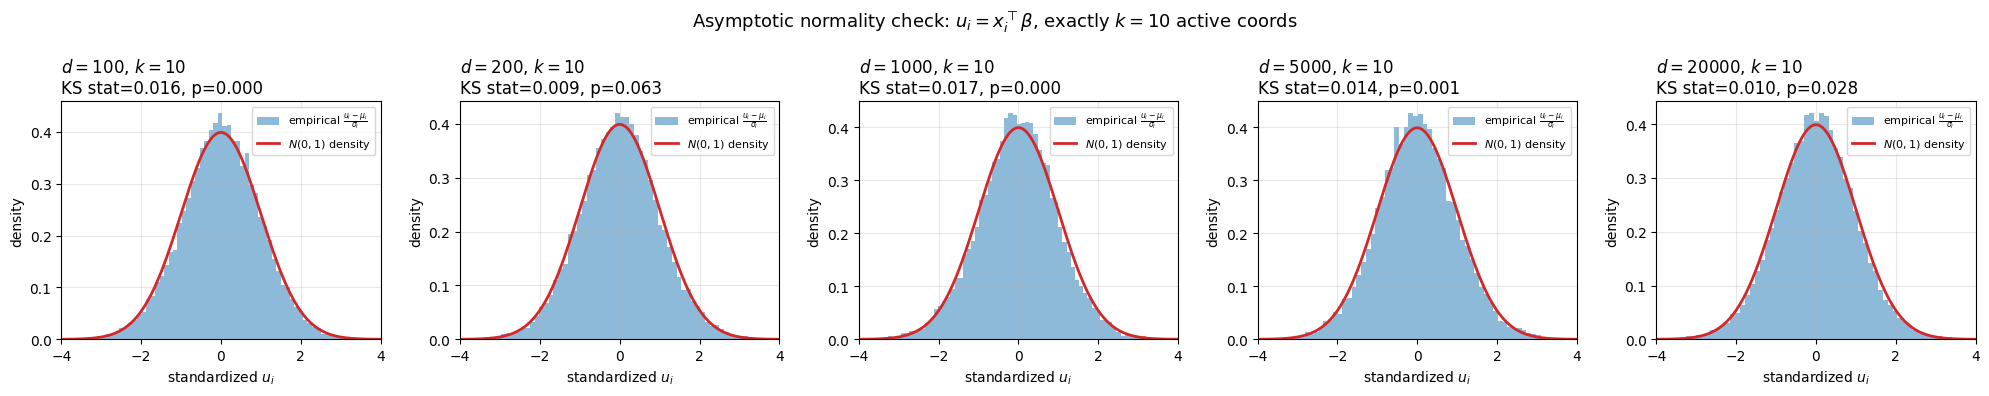

      d |     k |   skewness |  excess kurtosis |  KS stat | KS p-value
    100 |    10 |    -0.0039 |           0.3208 |   0.0147 |     0.0003
    200 |    10 |     0.3889 |           0.3364 |   0.0302 |     0.0000
   1000 |    10 |     0.1378 |           0.6105 |   0.0154 |     0.0002
   5000 |    10 |     0.0364 |           0.5939 |   0.0152 |     0.0002
  20000 |    10 |     0.0600 |           0.5405 |   0.0146 |     0.0004


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# Simulation: check asymptotic normality of u_i = x_i^T beta
# under a spike-and-slab distribution q(beta, z), where EXACTLY
# k=100 coordinates are active (z_j=1), regardless of d.
# As d increases (with k fixed), the "effective sparsity" k/d -> 0,
# so this probes a different asymptotic regime than iid Bernoulli(pi0).
# ============================================================

rng = np.random.default_rng(42)

# ---------- variational / prior-like parameters ----------
k_active = 10     # EXACT number of active coordinates (z_j=1), fixed
m_val = 1       # variational mean m_j (same for all active j)
rho_val = 1.0      # variational variance rho_j (same for all active j)

# ---------- design point x_i ----------
def sample_design_correlated(d, rng, block_size=10, rho=0.9):
    """
    Block-correlated design vector x_i in R^d (compound symmetry within blocks
    of size `block_size`, correlation `rho`), marginal mean 0, variance 1.
    """
    x_i = np.empty(d)
    start = 0
    while start < d:
        b = min(block_size, d - start)
        Sigma = (1 - rho) * np.eye(b) + rho * np.ones((b, b))
        block_sample = rng.multivariate_normal(np.zeros(b), Sigma)
        x_i[start:start + b] = block_sample
        start += b
    return x_i

# ---------- exact sampler for u_i^(d) = sum_j x_i^(j) * beta_j ----------
# with EXACTLY k_active nonzero beta_j per draw (fixed-size active set)
def sample_u_fixed_k(d, n_samples, rng, k_active=k_active,
                      m_val=m_val, rho_val=rho_val):
    if k_active > d:
        raise ValueError(f"k_active={k_active} nie może przekraczać d={d}")

    x_i = sample_design_correlated(d, rng)

    u = np.empty(n_samples)
    for s in range(n_samples):
        # wybierz dokładnie k_active indeksów spośród d, bez powtórzeń
        active_idx = rng.choice(d, size=k_active, replace=False)
        beta_slab = rng.normal(m_val, np.sqrt(rho_val), size=k_active)
        u[s] = np.dot(x_i[active_idx], beta_slab)

    return u, x_i

# ---------- theoretical mean/variance for fixed-k active set ----------
def theoretical_mean_var_fixed_k(x_i, k_active=k_active,
                                   m_val=m_val, rho_val=rho_val):
    """
    Dla losowania dokładnie k z d indeksów (bez powtórzeń, jednostajnie),
    P(j aktywny) = k/d dla każdego j (przez symetrię).
    Var_q(beta_j) warunkowo tak jak wcześniej: gamma=k/d.
    Uwaga: przy fixed-size subset istnieje słaba zależność między z_j
    (Cov(z_j,z_l) < 0 dla j != l), która tu jest pomijana w wariancji
    (przybliżenie - dokładna formuła wymagałaby uwzględnienia kowariancji
    wynikającej z losowania bez powtórzeń, tzw. hipergeometrycznej).
    """
    gamma = k_active / len(x_i)
    v_j = gamma * (rho_val + m_val**2) - gamma**2 * m_val**2
    mu_i = np.sum(x_i * gamma * m_val)
    sigma2_i = np.sum(x_i**2 * v_j)
    return mu_i, sigma2_i

# ---------- run simulation for increasing d (with k=100 fixed) ----------
d_values = [100, 200, 1000, 5000, 20_000]  # musi być d >= k_active
n_samples = 20_000

fig, axes = plt.subplots(1, len(d_values), figsize=(4 * len(d_values), 4))

for ax, d in zip(axes, d_values):
    u, x_i = sample_u_fixed_k(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var_fixed_k(x_i)
    sigma_i = np.sqrt(sigma2_i)

    u_std = (u - mu_i) / sigma_i

    ax.hist(u_std, bins=80, density=True, alpha=0.5, color='tab:blue',
             label='empirical $\\frac{u_i-\\mu_i}{\\sigma_i}$')
    grid = np.linspace(-4, 4, 300)
    ax.plot(grid, stats.norm.pdf(grid), color='tab:red', linewidth=2,
             label='$N(0,1)$ density')

    ks_stat, ks_pval = stats.kstest(u_std, 'norm')

    ax.set_title(f'$d={d}$, $k={k_active}$\nKS stat={ks_stat:.3f}, p={ks_pval:.3f}',
                 loc='left')
    ax.set_xlabel(r'standardized $u_i$')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.set_xlim(-4, 4)
    ax.grid(alpha=0.3)

fig.suptitle(f'Asymptotic normality check: $u_i=x_i^\\top\\beta$, exactly $k={k_active}$ active coords',
             fontsize=13)
plt.tight_layout()
plt.savefig('clt_spike_and_slab_fixed_k_check.png', dpi=150)
plt.show()

# ---------- additional numeric diagnostics ----------
print(f"{'d':>7} | {'k':>5} | {'skewness':>10} | {'excess kurtosis':>16} | {'KS stat':>8} | {'KS p-value':>10}")
for d in d_values:
    u, x_i = sample_u_fixed_k(d, n_samples, rng)
    mu_i, sigma2_i = theoretical_mean_var_fixed_k(x_i)
    u_std = (u - mu_i) / np.sqrt(sigma2_i)
    skew = stats.skew(u_std)
    kurt = stats.kurtosis(u_std)
    ks_stat, ks_pval = stats.kstest(u_std, 'norm')
    print(f"{d:7d} | {k_active:5d} | {skew:10.4f} | {kurt:16.4f} | {ks_stat:8.4f} | {ks_pval:10.4f}")

# STEP 2 - integral

d = 10: 100%|██████████| 20000/20000 [00:02<00:00, 8276.33it/s]


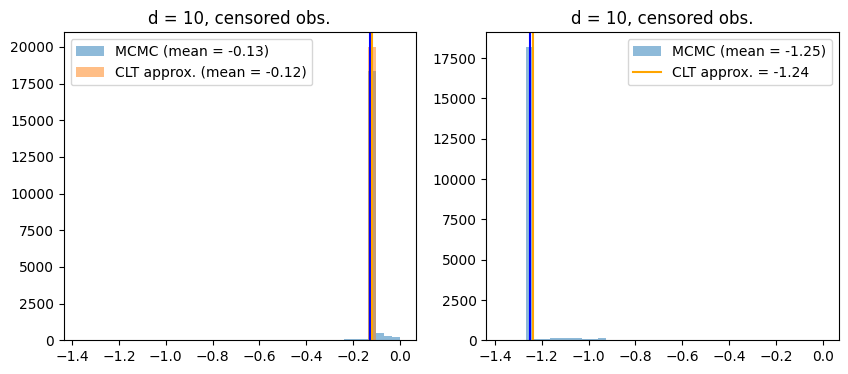

d = 100: 100%|██████████| 20000/20000 [00:02<00:00, 8271.00it/s]


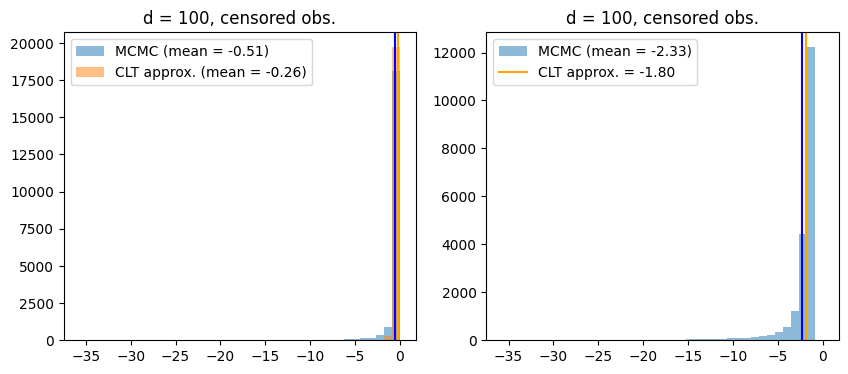

d = 1000: 100%|██████████| 20000/20000 [00:02<00:00, 7781.17it/s]


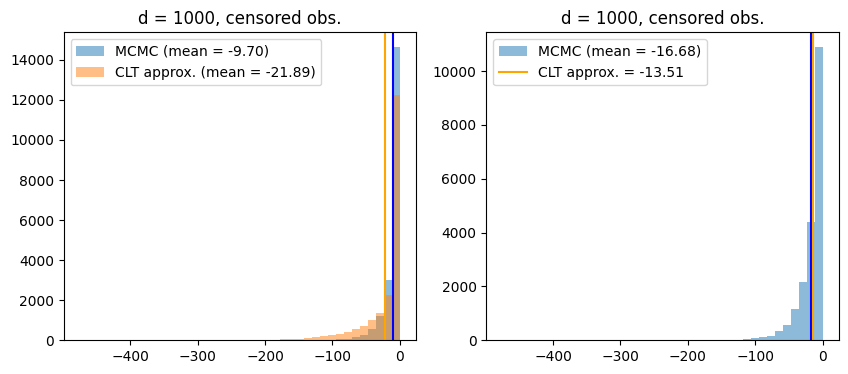

d = 10000: 100%|██████████| 20000/20000 [00:03<00:00, 5279.43it/s]


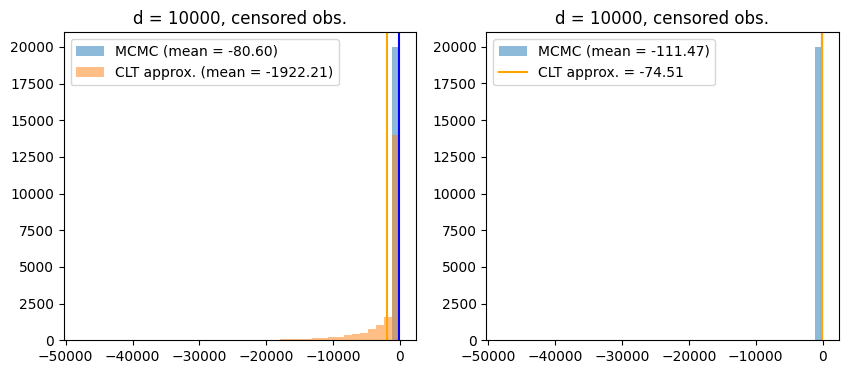

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm

d_list = [10, 100, 1_000, 10_000]
block_size = 20
perc_sig = 0.01
effect_size = 2
c_level = 10

#simulate data
def sample_design_correlated(d, rng, block_size=10, rho=0.9):
    """
    Block-correlated design vector x_i in R^d (compound symmetry within blocks
    of size `block_size`, correlation `rho`), marginal mean 0, variance 1.
    """
    x_i = np.empty(d)
    start = 0
    while start < d:
        b = min(block_size, d - start)
        Sigma = (1 - rho) * np.eye(b) + rho * np.ones((b, b))
        block_sample = rng.multivariate_normal(np.zeros(b), Sigma)
        x_i[start:start + b] = block_sample
        start += b
    return x_i

rng = np.random.RandomState(42)
n = 100 
it_mcmc = 20_000
sigma = 1

for d in d_list:
    x_i = sample_design_correlated(d, rng, block_size)
    
    sig = rng.choice([0,1], d, p =  [1-perc_sig, perc_sig]) 
    true_beta = sig * rng.normal(0,effect_size, d)
    m = true_beta + rng.normal(0, 1, d)
    s = 0.5 * np.ones(d) 
    gamma = 0.01 + 0.9 * sig

    mu = x_i @ true_beta 
    y = mu * np.ones(n) + rng.normal(0,1, n)

    l, u = np.percentile(y,c_level), np.percentile(y,100-c_level)

    w_mean = x_i @( gamma * m)

    v = gamma *s + gamma * (1-gamma) *m
    sigma_q = np.diag(v)
    w_var = x_i.T @ sigma_q @x_i

    ### integral at lower bound
    pbar = tqdm(range(0, it_mcmc), desc= f"d = {d}")

    res_l = np.empty(it_mcmc)
    res_in = np.empty(it_mcmc)

    clt_l = np.empty(it_mcmc)
    
    for it in pbar:
        
        sig_mcmc = (rng.random(d) < gamma).astype(int)
        beta = np.zeros(d)
        idx = np.where(sig_mcmc == 1)[0]
        beta[idx] = rng.normal(m[idx], s[idx])
        
        w = rng.normal(w_mean, w_var)

        z = (x_i.T @ beta - l) / sigma
        res_l[it] = norm.logcdf(z) 
        z = (w - l) / sigma
        clt_l[it] = norm.logcdf(z)
        
        z = (x_i.T @ beta - (l+2) ) / sigma
        res_in[it] = norm.logpdf(z)    

    in_clt_approx = -0.5*np.log(2*np.pi*sigma) - ((l+2 - w_mean)**2 + w_var)/(2*sigma)
    
    combined = np.concatenate([res_l, clt_l])
    bins = np.linspace(np.nanmin(combined), np.nanmax(combined), 41)  # 30 binów -> 31 krawędzi
    threshold = np.percentile(clt_l, 10)
    mean_above_5th = clt_l[clt_l > threshold].mean()

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    ax[0].hist(res_l, bins=bins, alpha=0.5, label=f"MCMC (mean = {res_l.mean():.2f})")
    ax[0].hist(clt_l, bins=bins, alpha=0.5, label=f"CLT approx. (mean = {clt_l.mean():.2f})")
    ax[0].axvline(res_l.mean(), color="blue")
    ax[0].axvline(clt_l.mean(), color="orange")
    
    ax[0].set_title(f"d = {d}, censored obs.")
    ax[0].legend()

    ax[1].hist(res_in, bins=bins, alpha=0.5, label=f"MCMC (mean = {res_in.mean():.2f})")
    ax[1].axvline(res_in.mean(), color="blue")
    ax[1].axvline(in_clt_approx, color="orange", label = f"CLT approx. = {in_clt_approx:.2f}")
    ax[1].set_title(f"d = {d}, censored obs.")
    ax[1].legend()
    
    plt.show()